[*********************100%***********************]  2 of 2 completed


,SPY,VXX
Date,,
2021-12-31,0.05,-0.27
2022-01-31,-0.05,0.16
2022-02-28,-0.03,0.12
2022-03-31,0.04,0.07
2022-04-30,-0.09,0.08
2022-05-31,0.00,-0.19
2022-06-30,-0.08,0.02
2022-07-31,0.09,-0.09
2022-08-31,-0.04,-0.08


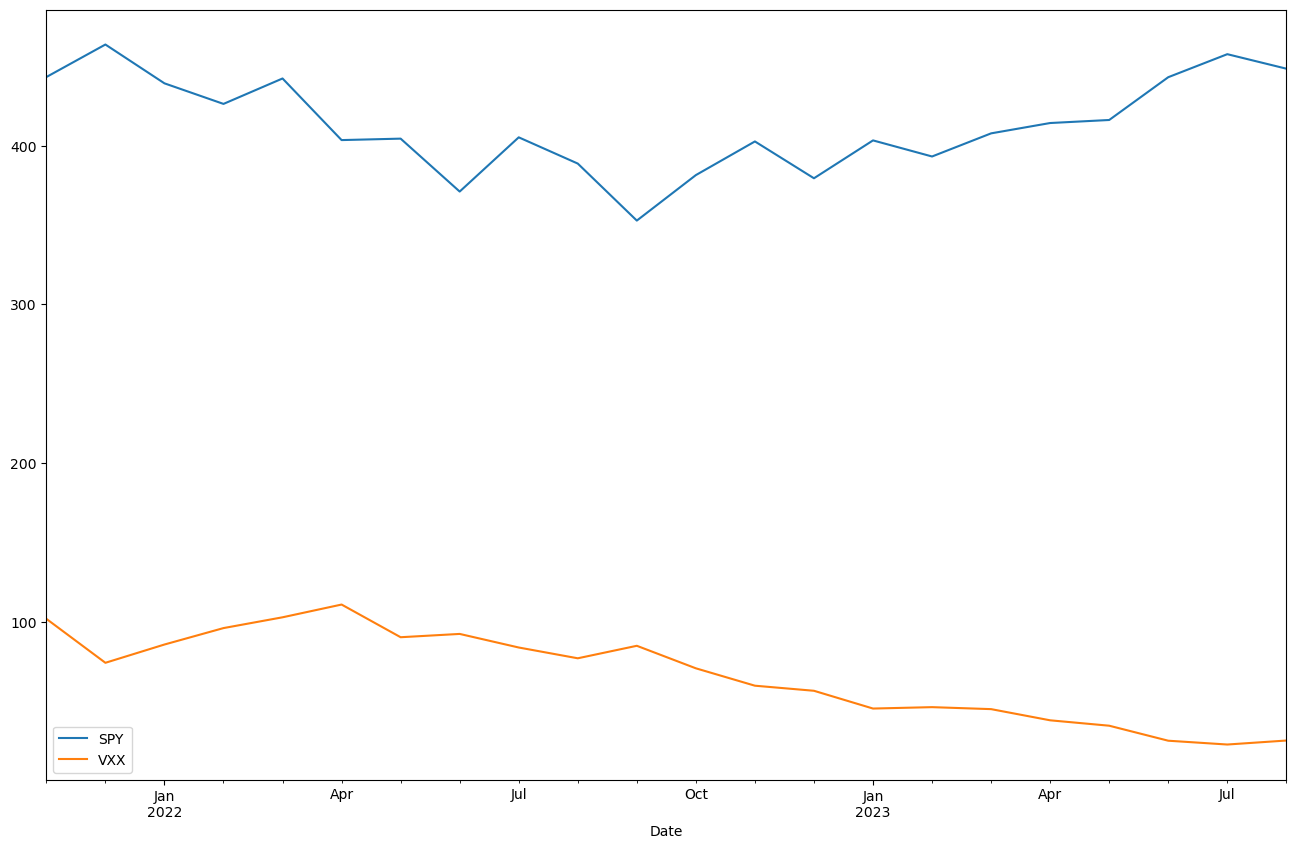

In [144]:
# Load modules
import pandas as pd
import numpy as np
from pandas_datareader import data as web
import yfinance as yf
import matplotlib.pyplot as plt
import math  
%matplotlib inline


# Get Raw Data 
# download historical prices
# Get the adjusted close prices of VXX 
price_history = web.DataReader(['VXX','SPY'], start = "2021-11-01")['Adj Close'].resample('M').ffill()
            
historical_return = price_history.pct_change().dropna()
display(historical_return)

price_history.plot(figsize=(16,10))
plt.show()

a:-0.012911
b:-0.281975


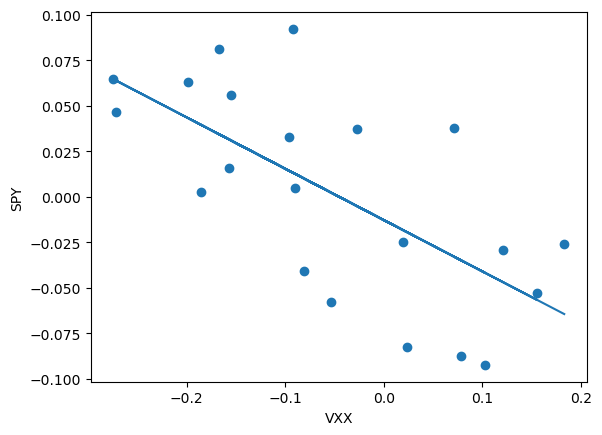

rsquared:0.453101


In [2]:
x=historical_return['VXX']
y=historical_return['SPY']
# calculate values of a and b that give least error
denominator=x.dot(x) - x.mean()*x.sum()
a=(y.mean()*x.dot(x)-x.mean()*x.dot(y))/denominator
print("a:%f"%a)
b=(x.dot(y)-y.mean()*x.sum())/denominator
print("b:%f"%b)

yhat = a+b*x

plt.scatter(x,y)
plt.plot(x, yhat)
plt.xlabel("VXX")
plt.ylabel("SPY")
plt.show()

d1=y-yhat
d2=y-y.mean()
rsquared=1-d1.dot(d1)/d2.dot(d2)
print("rsquared:%f"%rsquared)

In [3]:
# Create a data frame containing all the relevant variables
data = pd.DataFrame({'x': x, 'y': y})

# specify an OLS model and fit it
from statsmodels.formula.api import ols
model = ols("y ~ x", data).fit()

# inspect the various statistics derived from the fit
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     15.74
Date:                Tue, 08 Aug 2023   Prob (F-statistic):           0.000825
Time:                        10:52:31   Log-Likelihood:                 37.118
No. Observations:                  21   AIC:                            -70.24
Df Residuals:                      19   BIC:                            -68.15
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0129      0.010     -1.268      0.2

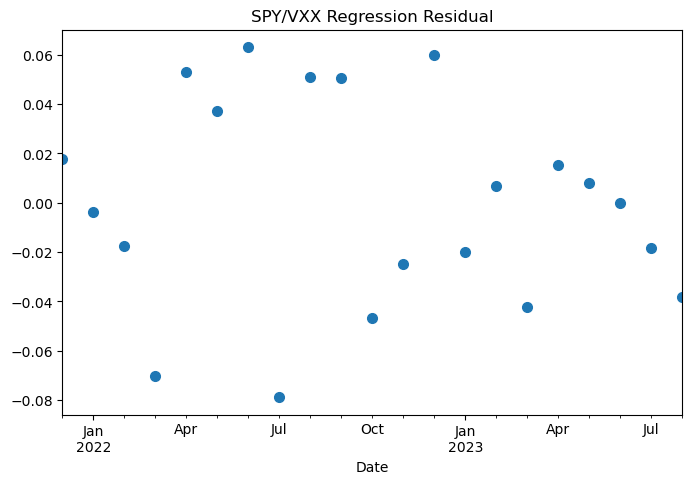

In [4]:
import matplotlib
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

historical_return['yhat-y']=yhat-y

historical_return['yhat-y'].plot(figsize=(8,5),title='SPY/VXX Regression Residual',style='.',ms=14)
plt.show()

In [5]:
price_history = web.get_data_yahoo(['VXX','SPY'], start = "2021-11-01")['Adj Close'].resample('M').ffill()
            
historical_return = price_history.pct_change().dropna()
display(historical_return)

[*********************100%***********************]  2 of 2 completed


,SPY,VXX
Date,,
2021-12-31,0.05,-0.27
2022-01-31,-0.05,0.16
2022-02-28,-0.03,0.12
2022-03-31,0.04,0.07
2022-04-30,-0.09,0.08
2022-05-31,0.00,-0.19
2022-06-30,-0.08,0.02
2022-07-31,0.09,-0.09
2022-08-31,-0.04,-0.08


[*********************100%***********************]  2 of 2 completed


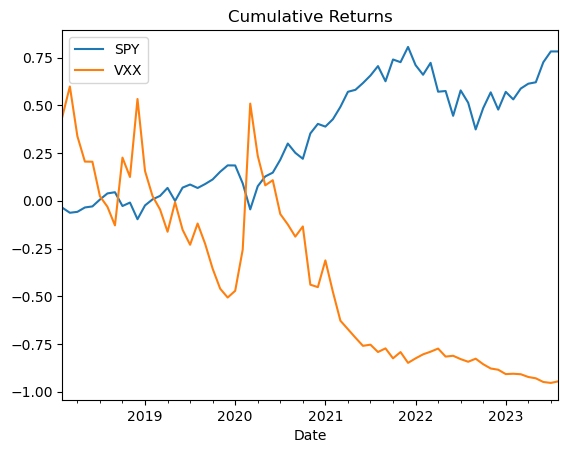

In [6]:
# Get Raw Data 
# download historical prices
# Get the adjusted close prices of GameStop and S&P 500
price_history = web.DataReader(['VXX','SPY'], start = "2015-01-01")['Adj Close'].resample('M').ffill()
            
historical_return = price_history.pct_change().dropna()

((1 + historical_return).cumprod() - 1).plot(title='Cumulative Returns')
plt.show()

In [7]:
# Load modules
from sklearn.model_selection import train_test_split

# Split Data into Training/Testing Sets

training_dataset, test_dataset = train_test_split(historical_return, test_size=0.25, random_state=0)

# descriptions
print(test_dataset.describe())
print(training_dataset.describe())

        SPY   VXX
count 17.00 17.00
mean   0.03 -0.07
std    0.06  0.15
min   -0.09 -0.35
25%   -0.01 -0.16
50%    0.03 -0.09
75%    0.06  0.03
max    0.13  0.26
        SPY   VXX
count 50.00 50.00
mean   0.00 -0.01
std    0.05  0.23
min   -0.12 -0.29
25%   -0.03 -0.15
50%    0.02 -0.08
75%    0.04  0.07
max    0.08  1.03


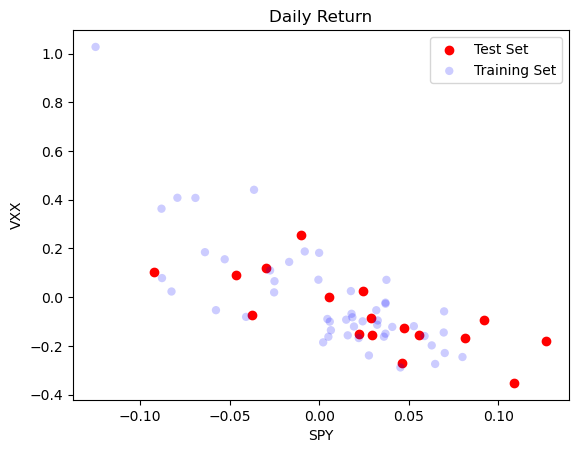

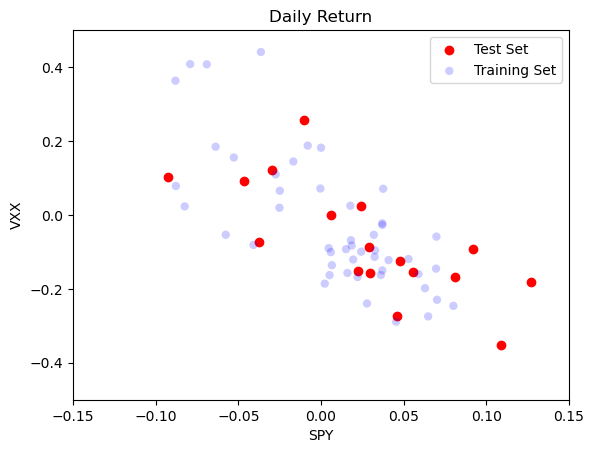

In [8]:
# Company Training & Test Sets

plt.scatter(test_dataset['SPY'], test_dataset['VXX'], color='red', 
            label='Test Set')
plt.scatter(training_dataset['SPY'], training_dataset['VXX'], color='blue', 
            alpha=0.2, edgecolors='none', label='Training Set')
plt.title("Daily Return")
plt.xlabel("SPY")
plt.ylabel("VXX")
plt.legend()
plt.show()

plt.scatter(test_dataset['SPY'], test_dataset['VXX'], color='red', 
            label='Test Set')
plt.scatter(training_dataset['SPY'], training_dataset['VXX'], color='blue', 
            alpha=0.2, edgecolors='none', label='Training Set')
plt.title("Daily Return")
plt.xlabel("SPY")
plt.ylabel("VXX")
plt.legend()
plt.xlim([-0.15, 0.15])
plt.ylim([-0.5, 0.5])
plt.show()

SPY's Beta to VXX: -3.6446935059905132


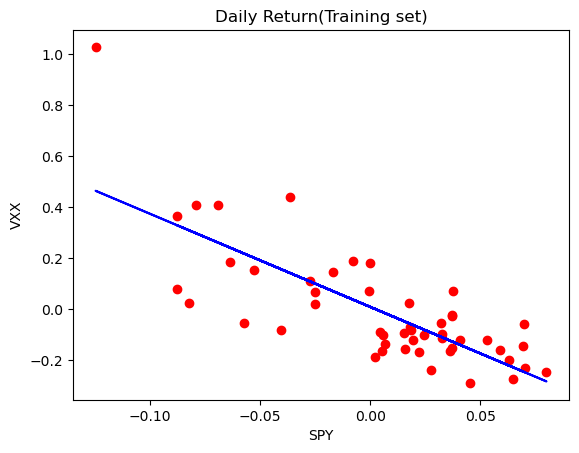

In [9]:
# Load modules
from sklearn.linear_model import LinearRegression

# Fitting Simple Linear Regression to the Training set
model_LinearRegression = LinearRegression()
X=pd.DataFrame(training_dataset['SPY'])
y=pd.DataFrame(training_dataset['VXX'])
model_LinearRegression.fit(X,y)
print("SPY's Beta to VXX:",model_LinearRegression.coef_[0][0])

# Visualizing the Training set results
viz_train = plt
viz_train.scatter(training_dataset['SPY'], training_dataset['VXX'], color='red')
viz_train.plot(training_dataset['SPY'], model_LinearRegression.predict(training_dataset[['SPY']]), color='blue')
viz_train.title("Daily Return(Training set)")
viz_train.xlabel("SPY")
viz_train.ylabel("VXX")
viz_train.show()

R^2 (Test): 0.10614809999532249


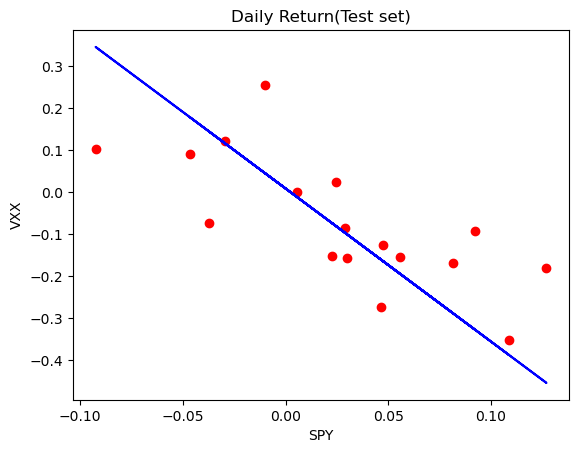

In [10]:
# Evaluate the predictions
print('R^2 (Test):',model_LinearRegression.score(pd.DataFrame(test_dataset['SPY']), pd.DataFrame(test_dataset['VXX'])) )

# Visualizing the Test set results
viz_test = plt
viz_test.scatter(test_dataset['SPY'], test_dataset['VXX'], color='red')
viz_test.plot(test_dataset['SPY'],model_LinearRegression.predict(test_dataset[['SPY']]) , color='blue')
viz_test.title("Daily Return(Test set)")
viz_test.xlabel("SPY")
viz_test.ylabel("VXX")
viz_test.show()

In [11]:
#Cross Validation

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

results = dict()

# evaluate a model
def evaluate_model(X, y, model):
    # define model evaluation method
    cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
    # evaluate model - MAE
    scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
    # force scores to be positive
    return np.absolute(scores)

# evaluate model
results['LinearRegression'] = evaluate_model(X, y, model_LinearRegression)
print('Mean MAE: %.5f' % (np.mean(results['LinearRegression'])))
print('Std MAE: %.5f' % (np.std(results['LinearRegression'])))

Mean MAE: 0.11248
Std MAE: 0.04855


In [12]:
# Huber Regression
from sklearn.linear_model import HuberRegressor

model_HuberRegressor = HuberRegressor()

# evaluate model
results['HuberRegressor'] = evaluate_model(X, y, model_HuberRegressor)
print('Mean MAE: %.5f' % (np.mean(results['HuberRegressor'])))
print('Std MAE: %.5f' % (np.std(results['HuberRegressor'])))

Mean MAE: 0.11079
Std MAE: 0.04937


/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

In [13]:
# RANSAC Regression
from sklearn.linear_model import RANSACRegressor

model_RANSACRegressor = RANSACRegressor()

# evaluate model
results['RANSACRegressor'] = evaluate_model(X, y, model_RANSACRegressor)
print('Mean MAE: %.5f' % (np.mean(results['RANSACRegressor'])))
print('Std MAE: %.5f' % (np.std(results['RANSACRegressor'])))

Mean MAE: 0.12215
Std MAE: 0.07460


In [14]:
# Theil Sen Regression
from sklearn.linear_model import TheilSenRegressor

model_TheilSenRegressor = TheilSenRegressor()

# evaluate model
results['TheilSenRegressor']  = evaluate_model(X, y, model_TheilSenRegressor)
print('Mean MAE: %.5f' % (np.mean(results['TheilSenRegressor'] )))
print('Std MAE: %.5f' % (np.std(results['TheilSenRegressor'] )))

Mean MAE: 0.11071
Std MAE: 0.05182


/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

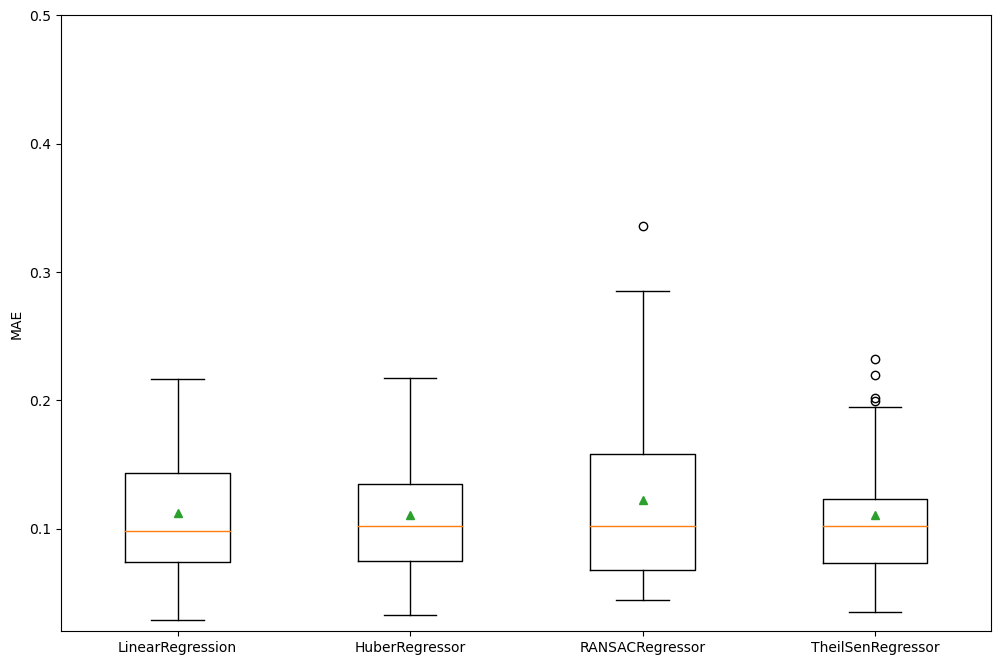

In [15]:
# plot model performance for comparison
plt.figure(figsize=(12,8))
plt.boxplot(results.values(), labels=results.keys(), showmeans=True)
plt.ylim([0.02, 0.5])
plt.ylabel("MAE")
plt.show()

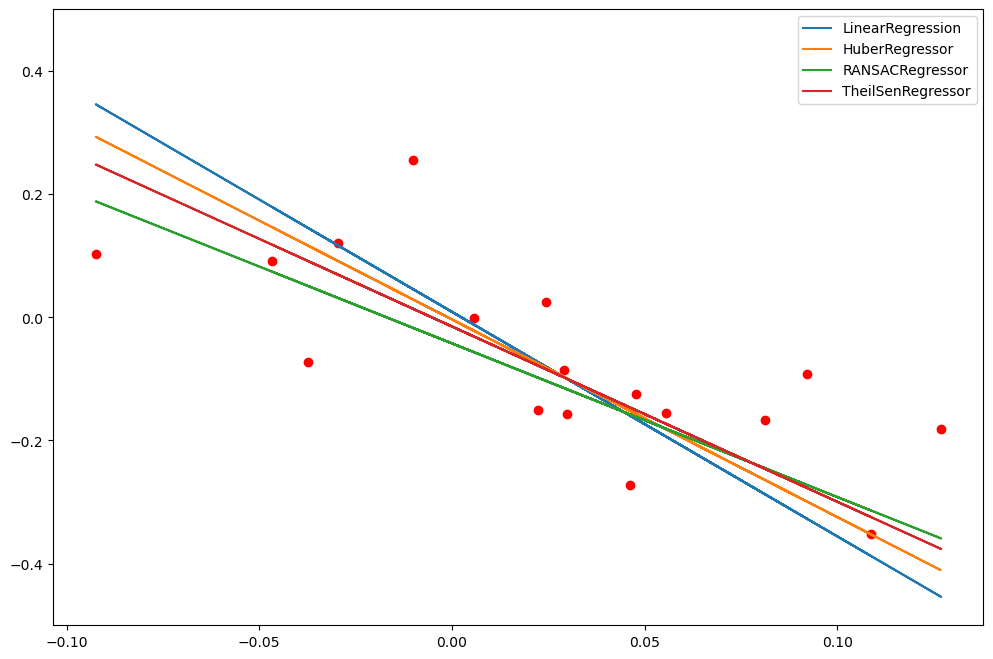

In [16]:
# plot the dataset
plt.figure(figsize=(12,8))
plt.scatter(test_dataset['SPY'], test_dataset['VXX'], color='red')

xaxis = test_dataset['SPY'].values

model_LinearRegression.fit(X,y)
yaxis = model_LinearRegression.predict(test_dataset[['SPY']])
# plot the line of best fit
plt.plot(xaxis, yaxis, label="LinearRegression")

model_HuberRegressor.fit(X,y['VXX'])
yaxis = model_HuberRegressor.predict(test_dataset[['SPY']])
# plot the line of best fit
plt.plot(xaxis, yaxis, label="HuberRegressor")

model_RANSACRegressor.fit(X,y)
yaxis = model_RANSACRegressor.predict(test_dataset[['SPY']])
# plot the line of best fit
plt.plot(xaxis, yaxis, label="RANSACRegressor")

model_TheilSenRegressor.fit(X,y['VXX'])
yaxis = model_TheilSenRegressor.predict(test_dataset[['SPY']])
# plot the line of best fit
plt.plot(xaxis, yaxis, label="TheilSenRegressor")

plt.legend()
plt.ylim([-0.5, 0.5])
plt.show()

In [121]:
# Fetch S&P 500 index data using yfinance
import yfinance as yf
VXX_index = yf.download('VXX', start='2018-01-01')
VXX_index.head()

# Fetch S&P 500 index data using yfinance
SPY_index = yf.download('SPY', start='2018-01-01')

SPY_index.head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,267.84,268.81,267.40,268.77,244.92,86655700
2018-01-03,268.96,270.64,268.96,270.47,246.47,90070400
2018-01-04,271.20,272.16,270.54,271.61,247.51,80636400
2018-01-05,272.51,273.56,271.95,273.42,249.16,83524000
2018-01-08,273.31,274.10,272.98,273.92,249.61,57319200


Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


<Axes: xlabel='Date'>

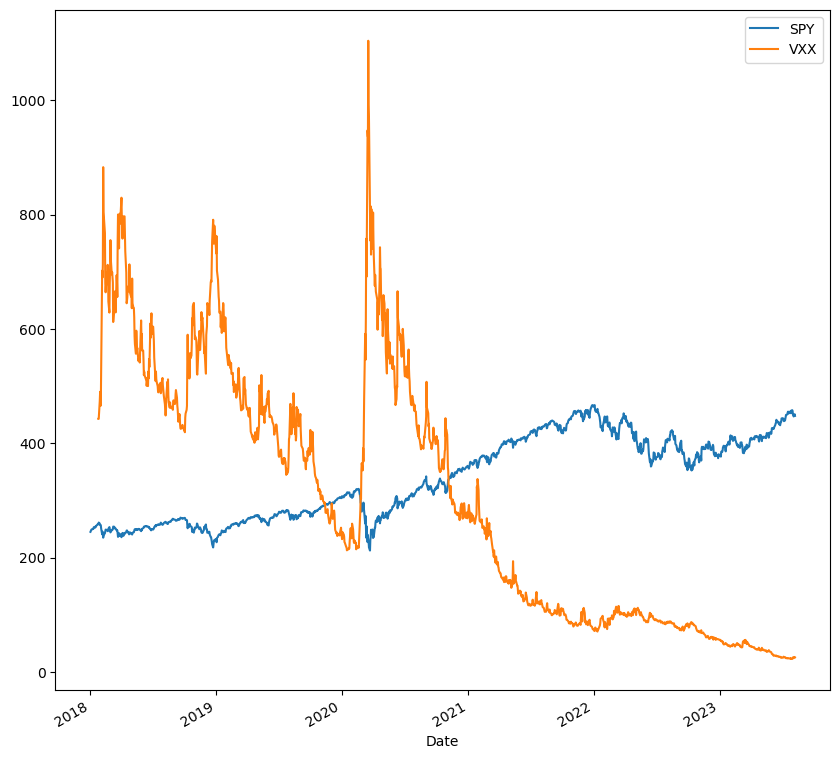

In [122]:
# Preprocess Data

# Print the columns to confirm the column names
print(SPY_index.columns)

# Select 'Adj Close' column before dropping NaN values
SPY_index = SPY_index['Adj Close'].dropna()
VXX_index = VXX_index['Adj Close'].dropna()

# Drop NaN values from both series
SPY_index = SPY_index.dropna()
VXX_index = VXX_index.dropna()

# Combine all the series into a DataFrame
dataset = pd.DataFrame({'SPY': SPY_index, 'VXX': VXX_index})

# Plot the dataset
dataset.plot(figsize=(10, 10))




,SPY,VXX
Date,,
2018-01-26,-40.99,0.00
2018-01-29,-45.19,6.94
2018-01-30,-47.47,3.28
2018-01-31,-47.62,0.33
2018-02-01,-44.90,-5.03
...,...,...
2023-08-02,"1,699.08",9.02
2023-08-03,"1,699.68",-0.32
2023-08-04,"1,629.81",3.57


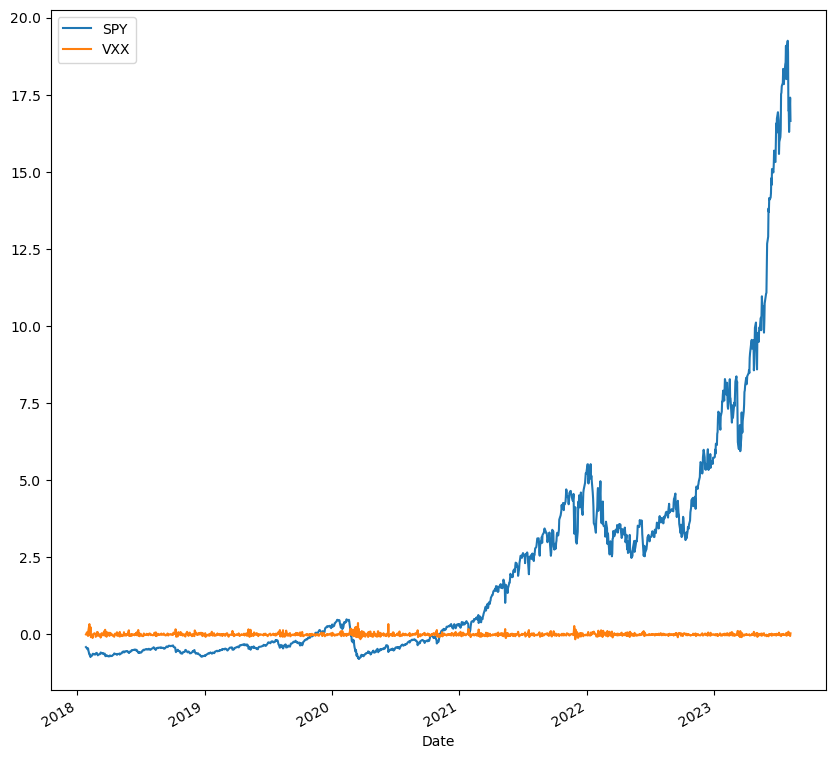

In [123]:
dataset2=dataset.copy()
for i in range(1,dataset.shape[0]):
    dataset2.iloc[i,0]=dataset.iloc[i,0]/dataset.iloc[i,1]-1
    dataset2.iloc[i,1]=dataset.iloc[i,1]/dataset.iloc[i-1,1]-1


dataset2.loc[0, 'SPY'] = np.nan
dataset2.loc[0, 'VXX'] = np.nan


dataset=dataset2.dropna()

dataset.plot(figsize=(10,10))

dataset*100

In [124]:
# Split Data into Training/Testing Sets

training_dataset=dataset.iloc[0:400,:]
test_dataset=dataset.iloc[400:,:]
# descriptions
display(test_dataset.describe())
display(training_dataset.describe())

X=training_dataset.iloc[:,1:2].copy()
y=training_dataset.iloc[:,0:1].copy()

,SPY,VXX
count,992.00,992.00
mean,3.13,-0.00
std,3.98,0.05
min,-0.79,-0.16
25%,0.06,-0.03
50%,2.62,-0.01
75%,4.22,0.02
max,19.26,0.37


,SPY,VXX
count,400.00,400.00
mean,-0.50,0.00
std,0.12,0.05
min,-0.73,-0.11
25%,-0.60,-0.03
50%,-0.50,-0.01
75%,-0.42,0.02
max,-0.18,0.34


/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected.

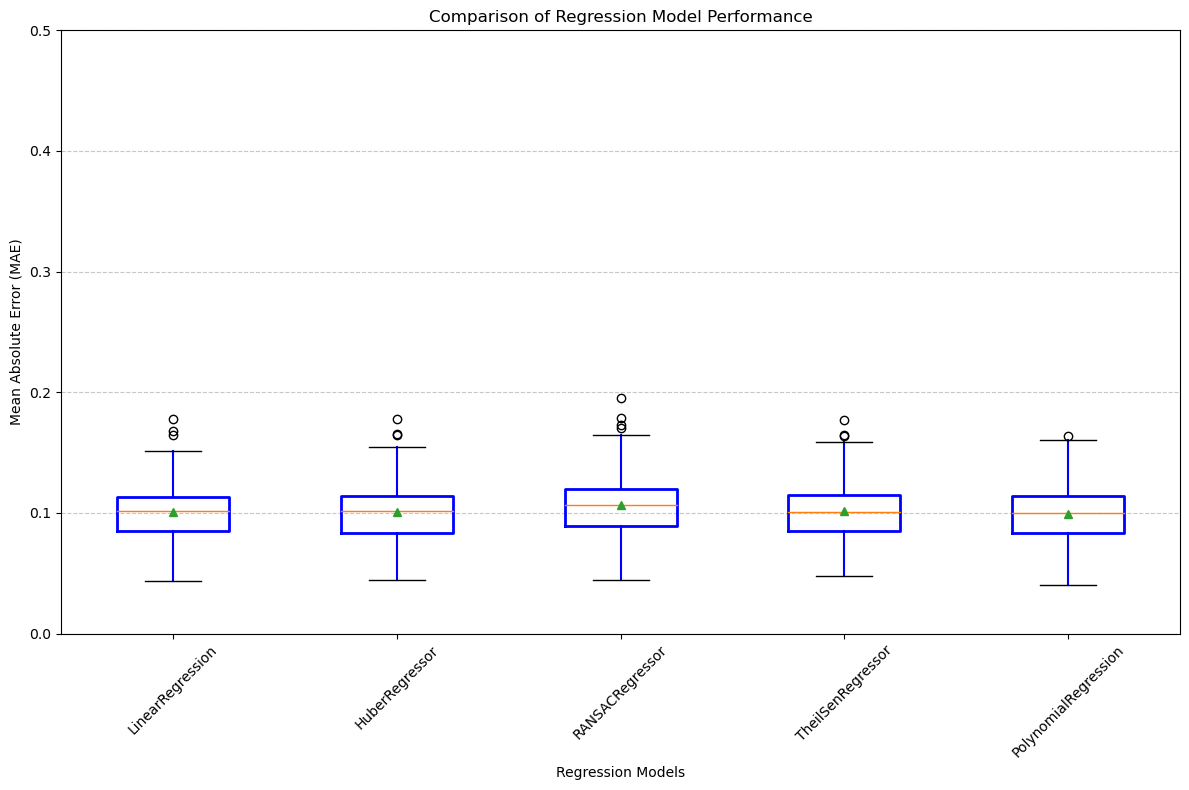

In [125]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RepeatedKFold, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Your data preparation code here

# Evaluate regression models
results = dict()

# Your evaluate_model function here

# Create the models
model_LinearRegression = LinearRegression()
model_HuberRegressor = HuberRegressor()
model_RANSACRegressor = RANSACRegressor()
model_TheilSenRegressor = TheilSenRegressor()
model_CubicRegression = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# Evaluate models and store results
results['LinearRegression'] = evaluate_model(X, y, model_LinearRegression)
results['HuberRegressor'] = evaluate_model(X, y, model_HuberRegressor)
results['RANSACRegressor'] = evaluate_model(X, y, model_RANSACRegressor)
results['TheilSenRegressor'] = evaluate_model(X, y, model_TheilSenRegressor)
results['PolynomialRegression'] = evaluate_model(X, y, model_CubicRegression)

# Plot model performance for comparison
plt.figure(figsize=(12, 8))
boxprops = dict(linestyle='-', linewidth=2, color='blue')  # Customize box appearance
whiskerprops = dict(linestyle='-', linewidth=1.5, color='blue')  # Customize whisker appearance

plt.boxplot(results.values(), labels=results.keys(), showmeans=True, boxprops=boxprops, whiskerprops=whiskerprops)
plt.title("Comparison of Regression Model Performance")
plt.xlabel("Regression Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.ylim([0, 0.5])  # Adjust the y-axis limits for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

R^2 (Test): -0.8279571745285286


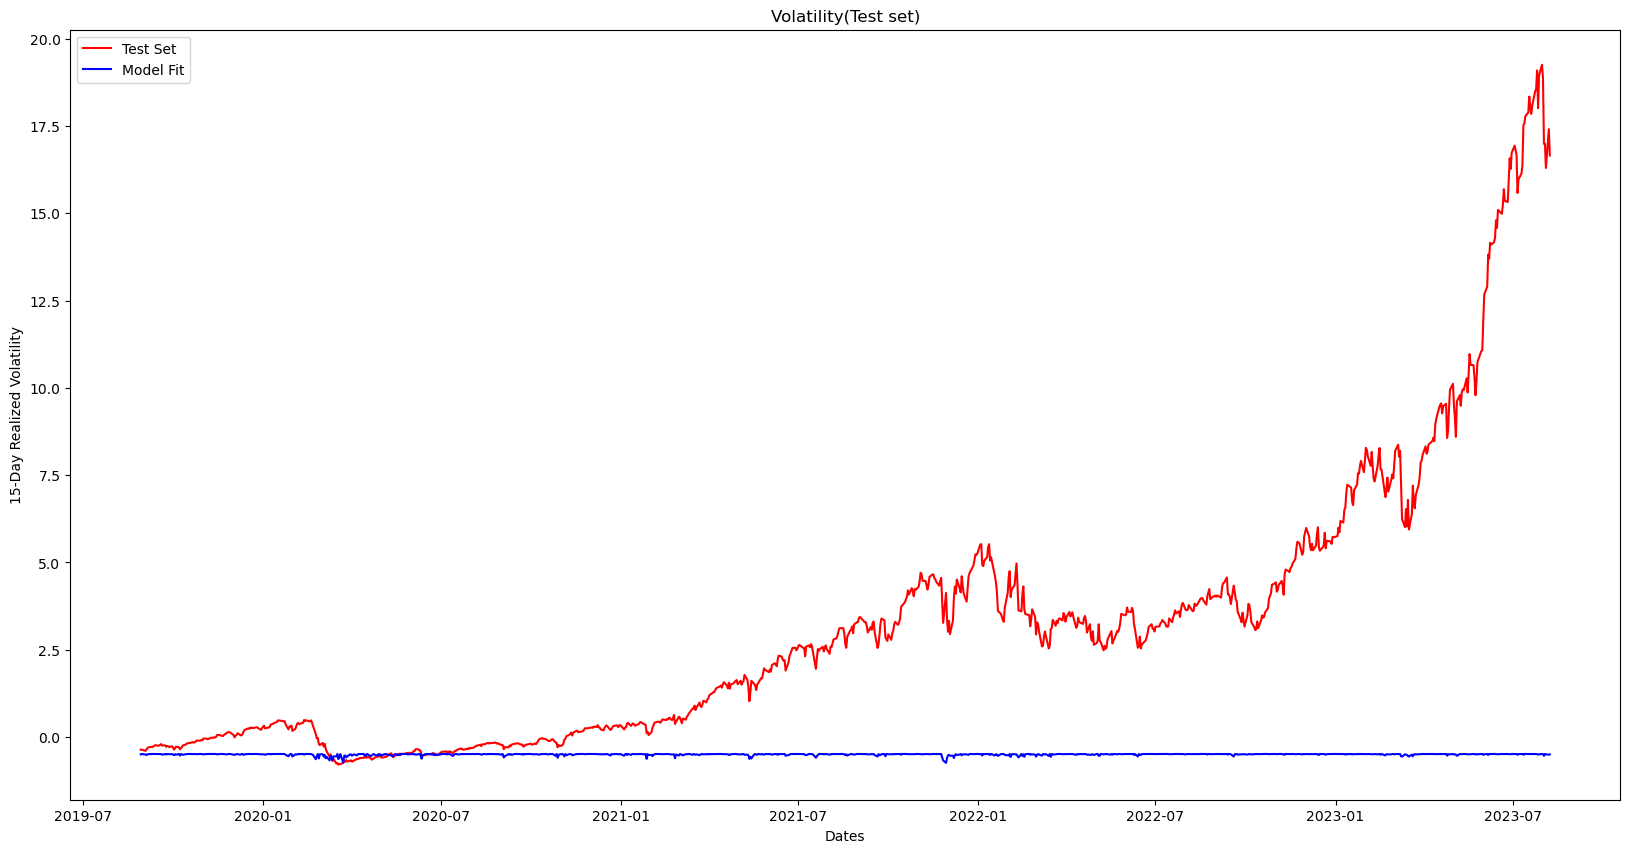

In [133]:
model_CubicRegression.fit(X,y)
# Model Validation of PolynomialRegression
print('R^2 (Test):', 
      model_CubicRegression.score(test_dataset.iloc[:,1:2],test_dataset.iloc[:,0]))


# Visualizing the Training set results
plt.figure(figsize=(20,10))
plt.plot(test_dataset.index, test_dataset.iloc[:,0], 
         color='red', label='Test Set')
plt.plot(test_dataset.index, model_CubicRegression.predict(test_dataset.iloc[:,1:2]), 
         color='blue', label='Model Fit')
plt.title("Volatility(Test set)")
plt.xlabel("Dates")
plt.ylabel("Realized Volatility")
plt.legend()
plt.show()

In [142]:
# Build a Strategy

dataset1=test_dataset.copy()
dataset1.insert(0,'Forecast_Return',predict)
dataset1.insert(0,'Model_Weight',dataset1.iloc[:,0]*0)

# Strategy
# If Forecast_Return>=0, long => Actual_Return
# If Forecast_Return<0, 0

for i in dataset1.index:
    if (dataset1.at[i,'Forecast_Return']>=0):
        dataset1.at[i,'Model_Weight']=1
    else:
        dataset1.at[i,'Model_Weight']=0   

# Strategy Return
dataset1['Strategy']=dataset1.iloc[:,0]*dataset1.iloc[:,2]
display(dataset1*100)

# Performance Calculation
((dataset1[['Strategy','SPY']]+1).cumprod() - 1).plot(title='Strategy Cumulative Returns',figsize=(8,6))
plt.show()

# Annualized Returns/Volatility 

performance=pd.DataFrame(pow((1 + dataset1[['Strategy','SPY']]).cumprod().iloc[-1,:],252/(dataset1[['Strategy','SPY']].shape[0]-1))-1)
performance.columns=[['Annualized Return']]

performance['Annualized volatility']=pd.DataFrame(dataset1[['Strategy','SPY']].std()*math.sqrt(252))

performance['Sharpe']=performance['Annualized Return'].values/performance['Annualized volatility'].values
performance




,Model_Weight,Forecast_Return,SPY,VXX,Strategy
Date,,,,,
2019-08-29,0.00,-50.32,-36.17,-4.18,-0.00
2019-08-30,0.00,-50.99,-36.56,0.56,-0.00
2019-09-03,0.00,-51.54,-39.59,4.41,-0.00
2019-09-04,0.00,-50.04,-34.88,-6.17,-0.00
2019-09-05,0.00,-50.39,-31.51,-3.71,-0.00
...,...,...,...,...,...
2023-08-02,0.00,-52.20,"1,699.08",9.02,0.00
2023-08-03,0.00,-50.87,"1,699.68",-0.32,0.00
2023-08-04,0.00,-51.42,"1,629.81",3.57,0.00


/Users/Paulami/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)
/Users/Paulami/anaconda3/lib/python3.11/site-packages/matplotlib/ticker.py:2094: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
/Users/Paulami/anaconda3/lib/python3.11/site-packages/matplotlib/ticker.py:2126: RuntimeWarning: overflow encountered in scalar subtract
  high = edge.ge(_vmax - best_vmin)


ValueError: arange: cannot compute length

<Figure size 800x600 with 1 Axes>

/Users/Paulami/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)
/var/folders/k2/c9gwjr4j5_30f7691byh491r0000gp/T/ipykernel_260/1184409016.py:32: RuntimeWarning: invalid value encountered in divide
  performance['Sharpe']=performance['Annualized Return'].values/performance['Annualized volatility'].values


,Annualized Return,Annualized volatility,Sharpe
Strategy,0.00,0.00,NaN
SPY,inf,63.25,inf
